# 05 · What to control for — and what NOT to (pathmc)

**The business decision behind the statistics.** Every effect estimate in every other notebook depends on
a choice made *before* any model runs: **which variables to control for** (put in the model / adjust for).
Get it wrong and the number is biased no matter how fancy the estimator. The instinct "throw in every
column we have" is actively dangerous. This is the notebook that lets you tell a skeptical CMO *exactly why*
you controlled for what you did.

### The four roles a variable can play — and the rule for each

To "**control for**" (equivalently *adjust for*, *condition on*) a variable $W$ means to hold it fixed when
comparing treated vs untreated — e.g. by including it in the regression. Whether that helps or hurts depends
entirely on $W$'s causal role between treatment $T$ and outcome $Y$:

- **Confounder** — a common cause of *both* $T$ and $Y$ (e.g. customer loyalty drives both who gets emailed
  and how much they spend). It opens a spurious "backdoor" path $T \leftarrow W \rightarrow Y$. → **Control
  for it.** Failing to is the classic omitted-variable bias.
- **Mediator** — a variable *on the causal path* $T \rightarrow W \rightarrow Y$ (the effect flows through
  it). → **Do NOT control for it** — you'd subtract out part of the very effect you're trying to measure.
- **Collider** — a common *effect* of $T$ and $Y$ ($T \rightarrow W \leftarrow Y$). Conditioning on a
  collider *opens* a path that was closed, **manufacturing** a correlation that isn't causal. → **Do NOT.**
- **M-bias collider** — a *pre-treatment* variable that is a collider between two hidden causes. → **Do NOT**
  — proof that "just control for everything measured before treatment" is wrong.

The tool that decides this formally is the **backdoor criterion** on the **DAG** (the causal graph): a valid
**adjustment set** is any set of variables that blocks every backdoor path from $T$ to $Y$ *without*
including a mediator or a descendant of $T$. `pathmc` reads the graph and enumerates the valid sets for us.

### What this notebook does

(a) a **gallery** of the four structures with the correct action — and, right after it, a working
simulation for the two that usually stay pictures (mediator over-control and M-bias); (b) we formalize
d-separation and the backdoor criterion, apply them **by hand**, and only then let `pathmc` enumerate the
admissible adjustment set and flag colliders straight from the DAG; (c) we show the bias of each wrong
choice **in euros** — predicted from the graph first, confirmed in simulation second, including the
disguised version everybody commits (filtering to responders); (d) we bound the residual risk from an
*unobserved* confounder with a sensitivity contour and an **E-value** (the minimum confounder strength
that could explain the effect away), read the full **posterior** of the effect, and close with real data
(LaLonde), a practitioner's covariate checklist and a one-paragraph decision memo.

7-step contract, with **identification** (which variables make the effect recoverable) — not estimation —
as the whole point.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import logging, pymc
logging.getLogger("pymc").setLevel(logging.CRITICAL + 1)  # SamplerWarnings log at ERROR — mute them all
import pathmc
from cmp import dgp, estimators as est, metrics, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
FIT = dict(draws=400, tune=400, chains=2) if FAST else dict(draws=1500, tune=1500, chains=4)
SEED = 17

## 1b · The four structures — a control-or-not gallery

Every "should I control for W?" question reduces to *what role W plays* between treatment T and
outcome Y:


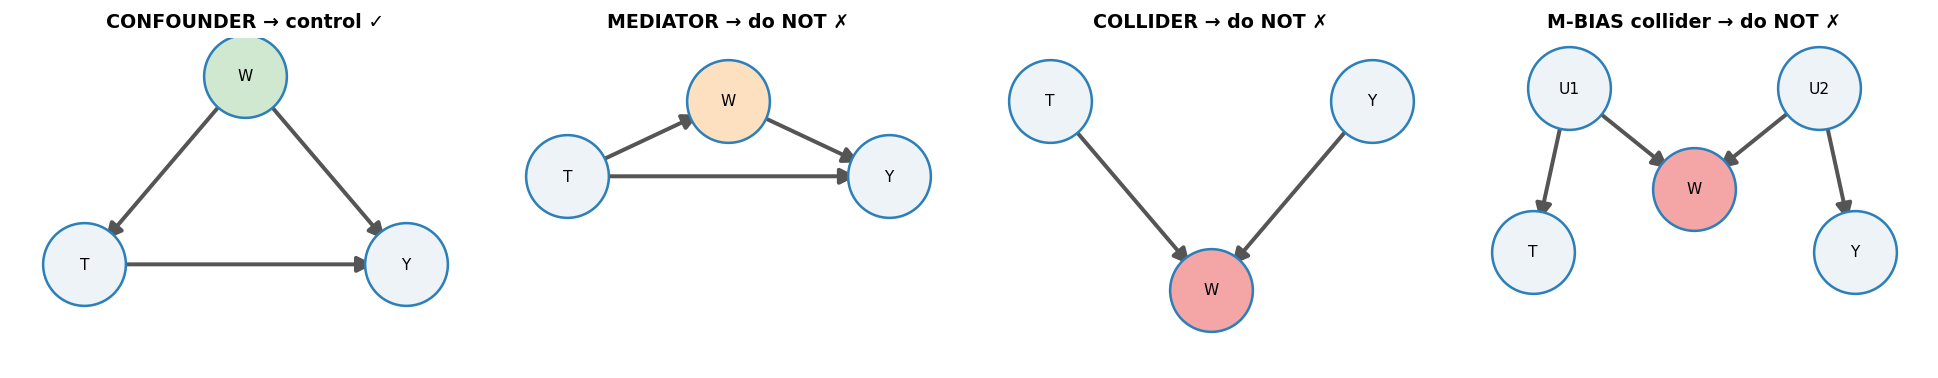

In [2]:
fig, ax = plt.subplots(1, 4, figsize=(15, 3.0))
plots.draw_dag(ax[0], {"W":(0.5,1.0),"T":(0.05,0.25),"Y":(0.95,0.25)},
    [("W","T"),("W","Y"),("T","Y")], node_colors={"W":"#cfe8cf"}, title="CONFOUNDER → control ✓")
plots.draw_dag(ax[1], {"T":(0.05,0.6),"W":(0.5,0.9),"Y":(0.95,0.6)},
    [("T","W"),("W","Y"),("T","Y")], node_colors={"W":"#fde0c0"}, title="MEDIATOR → do NOT ✗")
plots.draw_dag(ax[2], {"T":(0.05,0.9),"Y":(0.95,0.9),"W":(0.5,0.15)},
    [("T","W"),("Y","W")], node_colors={"W":"#f4a6a6"}, title="COLLIDER → do NOT ✗")
plots.draw_dag(ax[3], {"U1":(0.15,0.95),"U2":(0.85,0.95),"T":(0.05,0.3),"Y":(0.95,0.3),"W":(0.5,0.55)},
    [("U1","T"),("U1","W"),("U2","W"),("U2","Y")], node_colors={"W":"#f4a6a6"}, title="M-BIAS collider → do NOT ✗")
fig.tight_layout()

- **Confounder** (common cause of T and Y): **control** — it opens a backdoor path.
- **Mediator** (on the causal path T→W→Y): **do not** — you'd remove part of the effect you want.
- **Collider** (common effect of T and Y): **do not** — conditioning *opens* a spurious path.
- **M-bias collider** (pre-treatment, common effect of two latents that separately cause T and Y):
  **do not** — even a *pre-treatment* variable can be a trap. "Adjust for everything pre-treatment"
  is wrong.


## 1c · The other two traps, with data — the mediator first

The gallery's confounder and collider get a full simulation in §2–5. The other two panels are the ones
that usually stay pictures — so before moving on, we simulate **both** in miniature, and every rule in the
gallery has a number attached.

**Trap 1 — the mediator.** A discount email lifts spend two ways: directly (the customer redeems from the
email itself) and *indirectly*, by pulling the customer to the site where they spend more. Site visits sit
*on the causal path* — a **mediator**. We deliberately **randomize** $T$ (a coin-flip email) so there is no
confounding anywhere: whatever goes wrong below is purely the control choice. The data-generating model,
with $\sigma(z) = 1/(1+e^{-z})$:

$$
\begin{aligned}
T = \text{email} &\sim \text{Bernoulli}(0.5) &&\text{(randomized — no confounding by design)}\\[2pt]
M = \text{visited} &\sim \text{Bernoulli}\big(\sigma(-0.5 + 1.5\,T)\big) &&\text{(the email drives site visits)}\\[2pt]
Y = \text{spend} &= 20 + 3\,T + 8\,M + \varepsilon, \qquad \varepsilon \sim \mathcal N(0,\, 4^{2}) &&\text{(spend responds to both)}
\end{aligned}
$$

The number the CMO is asking for — "what does one email add to spend, *all channels included*?" — is the
**total effect**, which splits into a direct and an indirect (through-visits) piece:

$$
\tau_{\text{total}}
= \underbrace{3}_{\text{direct}}
+ \underbrace{8\,\big[P(M{=}1 \mid T{=}1) - P(M{=}1 \mid T{=}0)\big]}_{\text{indirect, via visits}}
= 3 + 8\,\big[\sigma(1.0) - \sigma(-0.5)\big] \approx 5.8 .
$$

Two regressions on the same simulated data — one with no controls, one "helpfully" controlling for
`visited`:

In [3]:
# --- Mediator: controlling for a variable ON the causal path changes the question ---
sig = lambda z: 1.0 / (1.0 + np.exp(-z))
N_MINI = 20_000                                   # plain numpy OLS — instant, no FAST gating needed
rng = np.random.default_rng(23)
T_m = (rng.uniform(size=N_MINI) < 0.5).astype(float)                       # randomized email
visited = (rng.uniform(size=N_MINI) < sig(-0.5 + 1.5 * T_m)).astype(float)
dmed = pd.DataFrame({"email": T_m, "visited": visited,
                     "spend": 20 + 3 * T_m + 8 * visited + rng.normal(0, 4, N_MINI)})

def ols_on(d, controls, treat="email", outcome="spend"):
    X = np.column_stack([np.ones(len(d)), d[treat].values] + [d[c].values for c in controls])
    return np.linalg.lstsq(X, d[outcome].values, rcond=None)[0][1]

dM = visited[T_m == 1].mean() - visited[T_m == 0].mean()      # how much the email moves visit probability
print(f"TRUTHS   direct = €3.00  ·  total = 3 + 8·ΔM = 3 + 8·{dM:.3f} ≈ €{3 + 8 * dM:.2f}")
print(f"no controls           : €{ols_on(dmed, []):.2f}   → the TOTAL effect (what the CMO asked for)")
print(f"controlling 'visited' : €{ols_on(dmed, ['visited']):.2f}   → only the DIRECT effect — the €{8 * dM:.2f} "
      "that flows through visits is silently subtracted")

TRUTHS   direct = €3.00  ·  total = 3 + 8·ΔM = 3 + 8·0.348 ≈ €5.78
no controls           : €5.69   → the TOTAL effect (what the CMO asked for)
controlling 'visited' : €2.92   → only the DIRECT effect — the €2.78 that flows through visits is silently subtracted


**Read-out (mediator).** With $T$ randomized, the no-controls regression is unbiased for the total effect
— and lands on it (up to sampling noise around the ≈ €5.8 truth). Adding `visited` does not "improve
precision"; it **changes the estimand**: the coefficient now answers *"what would the email do if we could
freeze site visits?"* — the direct effect (≈ €3), not the number the CMO asked about. Sometimes that split
is exactly what you want — notebook 04 builds the total/direct/indirect machinery deliberately. The sin is
not computing a direct effect; it is computing one *by accident* and calling it the campaign's lift: an
analyst who controls for post-send engagement quietly books only the fraction of the lift that bypasses
the site.

**Trap 2 — M-bias: the pre-treatment variable that is still a collider.** Two customer traits we never
observe: *deal-proneness* $U_1$ (drives historical coupon usage **and** who the targeting model emails) and
*brand affinity* $U_2$ (drives historical coupon usage **and** spend). Last year's coupon-redemption count
$W$ is measured **before** the send and correlates with both treatment and outcome — by every heuristic it
"looks like" a confounder. The data-generating model (exactly the gallery's fourth panel):

$$
\begin{aligned}
U_1,\, U_2 &\sim \mathcal N(0,1)\ \text{(unobserved)}, &
W &= U_1 + U_2 + \nu,\ \ \nu \sim \mathcal N(0,1),\\[3pt]
T &\sim \text{Bernoulli}\big(\sigma(0.8\,U_1)\big), &
Y &= 20 + 6\,T + 3\,U_2 + \varepsilon,\ \ \varepsilon \sim \mathcal N(0,\, 4^{2}).
\end{aligned}
$$

Trace the only indirect path: $T \leftarrow U_1 \to W \leftarrow U_2 \to Y$. It contains a **collider at
$W$** (two arrowheads meet there), so it is **already blocked** — §3 formalizes this rule. There is *no
open backdoor*: the naive estimate is unbiased before we touch anything. Conditioning on $W$ *opens* the
path:

In [4]:
# --- M-bias: a PRE-treatment variable that poisons the estimate when controlled ---
rng = np.random.default_rng(29)
U1, U2 = rng.normal(0, 1, N_MINI), rng.normal(0, 1, N_MINI)
T_b = (rng.uniform(size=N_MINI) < sig(0.8 * U1)).astype(float)
dmb = pd.DataFrame({"email": T_b,
                    "coupon_history": U1 + U2 + rng.normal(0, 1, N_MINI),   # measured PRE-treatment
                    "spend": 20 + 6 * T_b + 3 * U2 + rng.normal(0, 4, N_MINI)})
print(f"TRUE effect €6.00  ·  corr(coupon_history, email) = {dmb.coupon_history.corr(dmb.email):+.2f}, "
      f"corr(coupon_history, spend) = {dmb.coupon_history.corr(dmb.spend):+.2f}  → 'looks like' a confounder")
print(f"no controls                : €{ols_on(dmb, []):.2f}   → already unbiased (the collider at W keeps the path shut)")
print(f"controlling coupon_history : €{ols_on(dmb, ['coupon_history']):.2f}   → conditioning OPENED the path — "
      "bias from a 'safe' pre-treatment control")

TRUE effect €6.00  ·  corr(coupon_history, email) = +0.21, corr(coupon_history, spend) = +0.41  → 'looks like' a confounder
no controls                : €5.99   → already unbiased (the collider at W keeps the path shut)
controlling coupon_history : €5.22   → conditioning OPENED the path — bias from a 'safe' pre-treatment control


**Read-out (M-bias).** The naive estimate was already right; adding the pre-treatment,
correlated-with-everything covariate moved it *away* from the €6 truth by the better part of a euro. This
is the counterexample that kills the most common heuristic in applied work — **"control for everything
measured before treatment."** A timestamp is not a criterion.

Two honest caveats before anyone panics and deletes covariates. First, magnitude: pure M-bias is usually
**modest** next to confounder bias (Ding & Miratrix 2015) — compare the sub-€1 shift here with the +€3.5
confounding bias coming in §4. Second, the common real-world tangle: when a variable is plausibly *both* a
genuine confounder **and** an M-collider, adjusting is usually the lesser evil. The point is not "never
control pre-treatment variables"; it is that **the decision comes from the graph, not the timestamp** —
which is exactly why the rest of this notebook makes the graph explicit and lets *it* choose.

## 2 · Simulate a ground truth

`email → spend` with a **true effect of €6**. Around it: **`loyalty`** is a **confounder**
(drives both email and spend → must control); **`responded`** is a **collider** (caused by both
email and spend → tempting but poisonous); **`opened_email`** is a post-treatment descendant.

**The data-generating model** — exactly what `dgp.dag_control_demo` implements (defaults & seed in
`src/cmp/dgp.py`). Loyalty $L \sim \mathcal N(0,1)$; an **unobserved** engagement trait
$G \sim \mathcal N(0,1)$; $\sigma(z) = 1/(1+e^{-z})$:

$$
\begin{aligned}
T = \text{email} &\sim \text{Bernoulli}\big(\sigma(0.8\,L)\big)
  &&\text{(assignment is confounded by loyalty)}\\[2pt]
Y = \text{spend} &= 20 + 5\,L + 6\,T + 3\,G + \varepsilon, \qquad \varepsilon \sim \mathcal N(0,\, 4^{2})
  &&\text{(true ATE: the 6)}\\[2pt]
\text{opened\_email} &\sim \text{Bernoulli}\big(\sigma(1.5\,T + 0.7\,G)\big)
  &&(T \to \text{opened} \leftarrow G \to Y)\\[2pt]
\text{responded} &\sim \text{Bernoulli}\big(\sigma(1.2\,T + 0.05\,(Y - \bar Y))\big)
  &&(T \to \text{responded} \leftarrow Y).
\end{aligned}
$$

$L$ appears in both the treatment and the outcome equations — the backdoor that must be closed.
Neither `opened_email` nor `responded` appears in the spend equation, so controlling for them can
only manufacture bias: `responded` is the textbook collider (caused by $T$ and $Y$ directly), while
`opened_email` is the *subtler* trap — its collider path runs through the **unobserved** $G$, which
is why a DAG drawn without $G$ cannot warn you (the falsification section below catches it from data).


In [5]:
df, true_ate = dgp.dag_control_demo(n=2000, seed=SEED)
print(f"TRUE effect of email on spend = €{true_ate:.1f}")
df.head()

TRUE effect of email on spend = €6.0


,email,loyalty,opened_email,responded,spend
0,1.0,1.101262,1.0,0.0,27.705363
1,0.0,0.338431,0.0,0.0,17.425501
2,0.0,-0.539972,0.0,0.0,9.602566
3,0.0,-1.260242,0.0,0.0,5.056443
4,1.0,-1.894621,0.0,0.0,7.175152


## 3 · Identify — let the DAG choose the adjustment set

So far "blocking a path" has been a metaphor. Before handing the graph to `pathmc`, we make it a **rule you
can run by hand** — because the library below does nothing more than apply this rule exhaustively, and you
should be able to audit it.

**Rule 1 — when is a path blocked? (the d-separation rules).** A *path* between $T$ and $Y$ is any sequence
of edges connecting them, arrows pointing either way. Given a candidate control set $Z$, a path is
**blocked** iff it contains at least one of:

$$
\begin{gathered}
\underbrace{A \to B \to C \ \ \text{or}\ \ A \leftarrow B \to C \quad \text{with } B \in Z}_{\text{chain or fork: conditioning on the middle node closes it}}
\\[6pt]
\text{or}
\\[6pt]
\underbrace{A \to B \leftarrow C \quad \text{with } B \notin Z \text{ and no descendant of } B \text{ in } Z}_{\text{collider: closed by default — conditioning on } B \text{ (or its descendants) opens it}}
\end{gathered}
$$

where a *descendant* of $B$ is any variable reachable from $B$ by following arrows forward. In words:
conditioning on a **common cause** (fork) or an intermediate step (chain) removes the association that node
transmits — compare customers at the *same* loyalty and the "loyal people get emailed and spend more anyway"
signal disappears. Conditioning on a **common effect** (collider) does the reverse — it *creates* an
association that was never there. The intuition is **explaining away**: among customers who responded,
seeing high spend makes the email a *less necessary* explanation for the response, so email and spend
become negatively related inside that group even if they are independent overall.

**Rule 2 — the backdoor criterion.** A set $Z$ is an **admissible adjustment set** for the effect of $T$ on
$Y$ iff

$$
\begin{gathered}
\text{(a) no element of } Z \text{ is a descendant of } T,
\quad\text{and}\\[3pt]
\text{(b) } Z \text{ blocks every path from } T \text{ to } Y \text{ that starts with an arrow into } T .
\end{gathered}
$$

Paths starting with an arrow *into* $T$ are the **backdoor paths** — the routes along which "who got
treated" leaks information about the outcome. When (a) and (b) hold, the interventional quantity is
recovered by the **adjustment formula**

$$
P\big(Y \mid do(T{=}t)\big) \;=\; \sum_{z} P\big(Y \mid T{=}t,\, Z{=}z\big)\; P(z),
$$

where $do(T{=}t)$ means "set $T$ by intervention" (everyone gets the email) rather than "observe $T{=}t$"
(the loyal self-select into it). Plain reading: *compare treated vs untreated within look-alike strata of
$Z$, then average the strata back together with population weights.* Every regression adjustment in this
notebook is a linear-model shortcut for that formula.

**Run the algorithm by hand on our graph** (the one declared to `pathmc` below). Enumerate every path from
`email` to `spend`:

- `email → spend` — the causal path we are estimating. Leave it alone (blocking it, e.g. with a mediator,
  is §1c's trap);
- `email ← loyalty → spend` — starts with an arrow into `email` ⇒ a **backdoor**, open by default at the
  fork `loyalty` ⇒ any admissible $Z$ must contain `loyalty`;
- `email → responded ← spend` — a **collider** at `responded` ⇒ already blocked; putting `responded` in $Z$
  would *open* it (and `responded` is a descendant of $T$, failing condition (a) twice over);
- `email → opened_email` — a dead end in the *declared* graph (no arrow onward to `spend`), so it lies on
  no $T$–$Y$ path at all. Remember this one: it is exactly the blind spot the falsification section below
  exposes.

So $Z = \{\text{loyalty}\}$ is admissible (and minimal). That enumeration is **all** that
`m.adjustment_sets` does — read its output below and check it against your own answer.

**One more requirement the graph cannot show — positivity.** The adjustment formula only averages strata
where *both* arms exist: identification also needs $0 < P(T{=}1 \mid Z{=}z) < 1$ for every stratum $z$
(**overlap**). Here it holds by construction — $\sigma(0.8\,L) \in (0,1)$ for every finite loyalty — but
with a high-dimensional $Z$ it fails silently; nb01's Step-4 propensity histogram
(`est.propensity_scores` + `plots.overlap_plot`) is the standard check. Identification has two clauses —
**no open backdoors *and* positivity** — not one.


In [6]:
spec = '''
email        ~ b1*loyalty
opened_email ~ b2*email
responded    ~ b3*email + b4*spend
spend        ~ b5*email + b6*loyalty
'''
m = pathmc.model(spec, data=df)
print("Admissible adjustment set(s) for email → spend:", m.adjustment_sets("email", "spend"))
print("Identifiable:", m.is_identifiable("email", "spend"))
print()
for cand in [{"loyalty"}, {"loyalty","responded"}, {"loyalty","opened_email"}, set()]:
    warns = m.collider_warnings(cand, "email", "spend")
    print(f"control for {cand or '{}'}:  " + ("; ".join(warns) if warns else "OK — no collider opened"))

Admissible adjustment set(s) for email → spend: [{'loyalty'}]
Identifiable: True

control for {'loyalty'}:  OK — no collider opened
control for {'responded', 'loyalty'}:  'responded' is a collider between 'email' and 'spend'. Conditioning on it may open a spurious path and introduce bias.
control for {'loyalty', 'opened_email'}:  OK — no collider opened
control for {}:  OK — no collider opened


(Read the printout above as the machine doing the reasoning: it names `{loyalty}` as the one adjustment
set that closes the backdoor, confirms the effect is identifiable, and — critically — *warns* when a
candidate set includes `responded`, because that variable is a collider. This is the DAG logic from the
intro, applied automatically.)

## 4–5 · Estimate & Validate — every control choice, in €

Now we make the abstract warnings concrete and expensive. We estimate the same email→spend effect **five
ways**, each time controlling for a different set of variables, and compare to the known true €6:

- **nothing** (naive) — leaves the loyalty confounding in, so it's biased *up*;
- **{loyalty}** — the DAG-endorsed set; should land on €6;
- **{loyalty, responded}** — adds a *collider*, which opens a spurious path;
- **{loyalty, opened}** — adds a *post-treatment descendant*, another no-no;
- **everything** — the "throw it all in" instinct, which stacks the errors.

The punchline is that **the sign and rough size of each bias is predictable from the graph *plus the signs of
its edges* *before* you run anything** (here loyalty raises both emailing and spend): omitting a confounder biases up; conditioning on a collider or a post-treatment variable biases
in the direction of the association it induces. Controlling for more is *not* safer.

**The fitted model, in symbols** — the same OLS regression five times, differing only in the
control set $W$:

$$
\text{spend}_i = \beta_0 + \hat\tau\, \text{email}_i + \gamma^\top W_i + \varepsilon_i,
$$

reading off $\hat\tau$ for each choice of $W \in \big\{\varnothing,\; \{L\},\;
\{L, \text{responded}\},\; \{L, \text{opened}\},\; \{L, \text{responded}, \text{opened}\}\big\}$.
Same estimator, same data — *only the adjustment set changes*, so every difference between the bars
below is pure identification, not modeling.


naive (nothing)            € 9.45   (error +3.45)
{loyalty} ✓                € 6.09   (error +0.09)
{loyalty,responded} ✗      € 5.58   (error -0.42)
{loyalty,opened} ✗         € 5.45   (error -0.55)
everything ✗               € 4.97   (error -1.03)


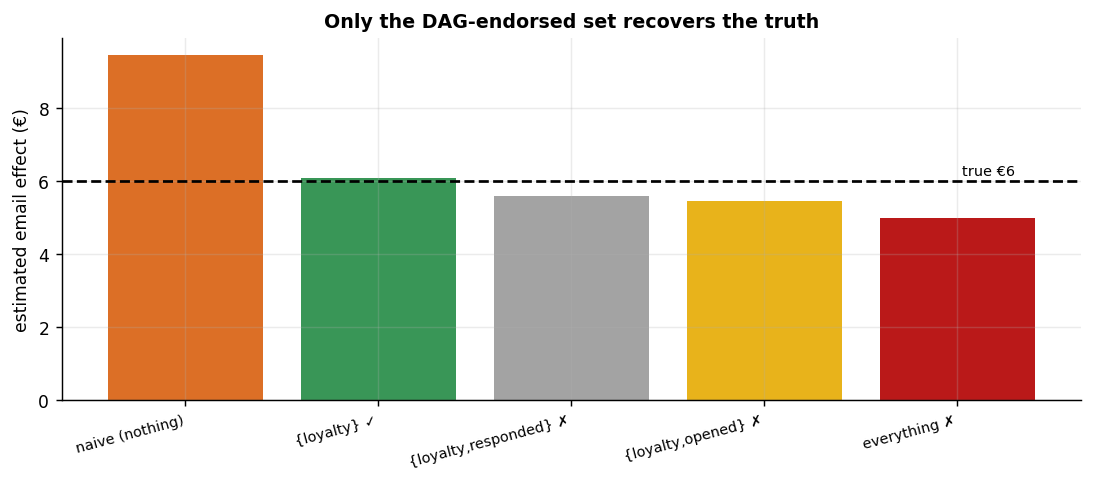

In [7]:
def ols_effect(controls):
    X = np.column_stack([np.ones(len(df)), df["email"].values] + [df[c].values for c in controls])
    return np.linalg.lstsq(X, df["spend"].values, rcond=None)[0][1]

choices = {
    "naive (nothing)": [], "{loyalty} ✓": ["loyalty"],
    "{loyalty,responded} ✗": ["loyalty","responded"],
    "{loyalty,opened} ✗": ["loyalty","opened_email"],
    "everything ✗": ["loyalty","responded","opened_email"],
}
ests = {k: ols_effect(v) for k, v in choices.items()}
fig, ax = plt.subplots(figsize=(8.5, 3.8))
cols = [plots.ORANGE, plots.GREEN, plots.GREY, plots.GOLD, "#b30000"]
ax.bar(range(len(ests)), list(ests.values()), color=cols, alpha=0.9)
ax.axhline(true_ate, color="k", ls="--"); ax.text(4.3, true_ate+0.15, f"true €{true_ate:.0f}", ha="right", fontsize=8)
ax.set_xticks(range(len(ests))); ax.set_xticklabels(list(ests.keys()), rotation=15, ha="right", fontsize=8)
ax.set_ylabel("estimated email effect (€)"); ax.set_title("Only the DAG-endorsed set recovers the truth")
fig.tight_layout()
for k, v in ests.items(): print(f"{k:26s} €{v:5.2f}   (error {v-true_ate:+.2f})")

**How to read this.** Only the green bar — `{loyalty}`, the set the DAG endorsed — lands on the true €6.
The naive bar overshoots (confounding left in); adding the collider `responded` or the hidden collider `opened_email` (see the falsification test below) *pulls the estimate away* even though we already had the right confounder; and "everything" is the
worst of all. The moral for a practitioner is blunt: **the model can't tell you it's biased — the bars all
look like plausible numbers.** The only defence is choosing the control set from the causal graph *before*
looking at the estimates, which is precisely what makes the answer defensible to a skeptic.


### Depth check — predict the bars before running them

§4–5's preamble claimed the sign *and rough size* of each bias is readable off the graph. That deserves a
derivation, not an assertion. Both wrong directions follow from two pocket formulas.

**1 · Omitted confounder ⇒ omitted-variable bias (OVB).** Regress spend on email alone under the §2 DGP
($Y = 20 + 5L + 6T + 3G + \varepsilon$, with the engagement trait $G$ independent of $T$). The naive
coefficient converges to

$$
\hat\tau_{\text{naive}} \;\xrightarrow{\;p\;}\; \tau \;+\; \beta_L\,\big(\mathbb E[L \mid T{=}1] - \mathbb E[L \mid T{=}0]\big),
\qquad \beta_L = 5,
$$

the classic OVB formula specialized to a binary treatment: **bias = (effect of the omitted variable on the
outcome) × (its imbalance across arms)**. Both factors are positive here — loyalty raises spend
($\beta_L = 5 > 0$) and loyal customers get emailed more (positive imbalance) — so the graph plus edge
signs says *biased up*, and the DGP coefficients say *by how much*. The cell below computes the prediction
and holds it against the naive bar.

**2 · Conditioned collider ⇒ explaining-away, with a sign rule.** For a collider receiving
$C \leftarrow a\,T$ and $C \leftarrow b\,Y$, conditioning on $C$ induces a non-causal $T$–$Y$ association of
sign $-\,\mathrm{sign}(a\,b)$. For `responded`, $a = 1.2 > 0$ and $b = 0.05 > 0$, so the induced association
is **negative** — the pocket rule: *both arrows into the collider positive ⇒ conditioning biases the
estimate down.* That is the direction of all three ✗ bars. (The M-bias example of §1c runs on the same
explaining-away algebra, just with one extra hop through the latents.)

In [8]:
# OVB check: predicted bias = beta_L × (loyalty imbalance across arms) — no refit needed
dL = df.loyalty[df.email == 1].mean() - df.loyalty[df.email == 0].mean()
pred_bias = 5.0 * dL
obs_bias = ests["naive (nothing)"] - true_ate
print(f"loyalty imbalance across arms      ΔL = {dL:+.3f}")
print(f"predicted naive bias    β_L·ΔL = 5 × {dL:.3f} = {pred_bias:+.2f}")
print(f"observed naive bias     (naive bar − truth)   = {obs_bias:+.2f}   → they agree to €{abs(pred_bias - obs_bias):.2f}")
err_resp, err_open, err_all = (ests[k] - true_ate
                               for k in ["{loyalty,responded} ✗", "{loyalty,opened} ✗", "everything ✗"])
print(f"\ncollider sign rule: a = +1.2, b = +0.05  ⇒  sign(−a·b) < 0 — and indeed all three ✗ bars err "
      f"downward: {err_resp:+.2f}, {err_open:+.2f}, {err_all:+.2f}")

loyalty imbalance across arms      ΔL = +0.691
predicted naive bias    β_L·ΔL = 5 × 0.691 = +3.46
observed naive bias     (naive bar − truth)   = +3.45   → they agree to €0.01

collider sign rule: a = +1.2, b = +0.05  ⇒  sign(−a·b) < 0 — and indeed all three ✗ bars err downward: -0.42, -0.55, -1.03


The graph gave the *directions* before any data existed; the DGP's coefficients turned direction into
magnitude; and the simulation confirms the OVB prediction to within a few cents. That is the standard to
hold an observational read to: **if you cannot pre-state the sign of the bias a proposed control would
create or remove, you are not ready to defend the estimate** — and when your predicted sign and the data
disagree, suspect the graph (the falsification test below makes that suspicion operational).

### When the machine is wrong — falsify the DAG against the data

Look back at Step 3: pathmc **green-lit** `{opened_email, loyalty}` ("OK — no collider opened"), yet the bar
above shows that exact set is **biased** (−€0.55). That is not a pathmc bug — it is the single most important
caveat about DAG-based methods: **the machine reasons only about the graph *we drew*.** Our graph declares
`opened_email ~ email`, but the true process has a **hidden engagement trait** driving both `opened_email`
and `spend` — making `opened_email` a collider pathmc cannot see, so conditioning on it opens
`email → opened_email ← trait → spend`.

You can catch this *without* knowing the hidden trait: every DAG makes **testable conditional-independence
claims**. Our declared graph implies `opened_email ⊥ spend | {email, loyalty}` — so test it against the data:

In [9]:
falsif = m.test_implications(alpha=0.05)   # check the declared DAG's implied independences against the data
print(f"Declared-DAG conditional-independence claims tested: {falsif.n_tests}  ·  violations: {falsif.n_violations}")
print(falsif.violations[["x", "y", "conditioning_set", "p_value"]].to_string(index=False))

Declared-DAG conditional-independence claims tested: 4  ·  violations: 1
           x     y conditioning_set      p_value
opened_email spend   email, loyalty 1.314202e-19


The data **rejects** `opened_email ⊥ spend | {email, loyalty}` (p ≈ 1e-19): a testable implication of the
graph we drew is false, so the graph is misspecified. *That* is why `{opened_email, loyalty}` comes out
biased even though pathmc approved it — the tool was faithful to a wrong graph. **The lesson: a causal DAG is
an assumption. Let the machine pick the adjustment set from the graph, but *falsify the graph against the
data* (here, `test_implications`) before you trust its verdict.**

### 4b · The same trap without a regression — analyzing only responders

Nobody on a marketing team types `responded` into a regression and feels clever about it. What teams do
instead — constantly — is **filter**: *"let's measure the email's effect among customers who engaged."* The
two are the same act: **subsetting a dataset IS conditioning on the subsetting variable.** Keeping only
`responded == 1` conditions every downstream estimate on the collider $T \to \text{responded} \leftarrow Y$,
opening the same non-causal path as §4's grey bar — only now it is invisible, because no model summary will
ever list `responded` as a covariate.

In [10]:
sub = df[df.responded == 1]                    # the innocuous-looking "engaged customers" filter
print(f"filtered to responders: {len(sub):,} of {len(df):,} customers ({len(sub) / len(df):.0%}) — hardly a niche slice")
print(f"true effect €{true_ate:.1f}")
print(f"  full sample,     {{loyalty}}  : €{ols_on(df, ['loyalty']):.2f}   (the defensible number)")
print(f"  responders only, nothing    : €{ols_on(sub, []):.2f}   (confounding AND selection at once)")
print(f"  responders only, {{loyalty}}  : €{ols_on(sub, ['loyalty']):.2f}   (the RIGHT confounder cannot close a path the filter opened)")

# Is the responders-only shortfall persistent, or this sample's luck? Re-run on fresh samples.
NS_SUB = 12 if FAST else 30
errs_sub = []
for sd in range(NS_SUB):
    d_s, _ = dgp.dag_control_demo(n=2000, seed=400 + sd)
    errs_sub.append(ols_on(d_s[d_s.responded == 1], ["loyalty"]) - true_ate)
errs_sub = np.array(errs_sub)
print(f"\nresponders-only + {{loyalty}} across {NS_SUB} fresh samples: mean bias {errs_sub.mean():+.2f} "
      f"(sd {errs_sub.std():.2f}) — a persistent shortfall, not sampling luck: no covariate adjustment inside "
      "the subset can close a selection-opened path.")

filtered to responders: 1,194 of 2,000 customers (60%) — hardly a niche slice
true effect €6.0
  full sample,     {loyalty}  : €6.09   (the defensible number)
  responders only, nothing    : €8.73   (confounding AND selection at once)
  responders only, {loyalty}  : €5.71   (the RIGHT confounder cannot close a path the filter opened)

responders-only + {loyalty} across 12 fresh samples: mean bias -0.43 (sd 0.39) — a persistent shortfall, not sampling luck: no covariate adjustment inside the subset can close a selection-opened path.


**Read-out.** Inside the responders subset the naive read is badly off, and — the important line — handing
the filtered analysis the *exactly correct* confounder still leaves a bias that does not average away
across fresh samples. The problem is not an omitted variable; it is an **opened path**, and the filter
itself opened it. Recognize the pattern in the wild, because it rarely announces itself:

- **converter-only attribution** — "of the customers who purchased, which touchpoints did they see?";
- **opened-email lift reads** — "the subject line's effect among opens";
- **survey-based incrementality** — only responders answer the survey;
- **"active users" dashboards** — activity is caused by both the campaign and the outcome it proxies.

The fix is never a better covariate *inside* the subset — it is refusing the filter (estimate on everyone
the campaign could have touched) or modeling the selection explicitly.

### 5b · Recovery across many seeds — unbiased *and* calibrated?

A single sample can land a little off; the real test of an estimator is whether it is **centred on the truth over repeated samples** (unbiased, not just lucky here) and whether its intervals **cover** the truth at their stated rate. We refit on many fresh samples and check both.

naive (nothing)            mean € 9.49  bias +3.49  sd 0.30
{loyalty} ✓                mean € 5.94  bias -0.06  sd 0.24
{loyalty,responded} ✗      mean € 5.56  bias -0.44  sd 0.32
{loyalty,opened} ✗         mean € 5.37  bias -0.63  sd 0.24
everything ✗               mean € 5.00  bias -1.00  sd 0.32

The DAG-endorsed set is centred on the truth (bias -0.06 across 12 seeds — sampling noise, not a fixed offset); the collider / over-control sets carry a PERSISTENT bias
(a fixed offset that does NOT shrink across seeds, unlike sampling noise) — exactly what a single sample can hide.


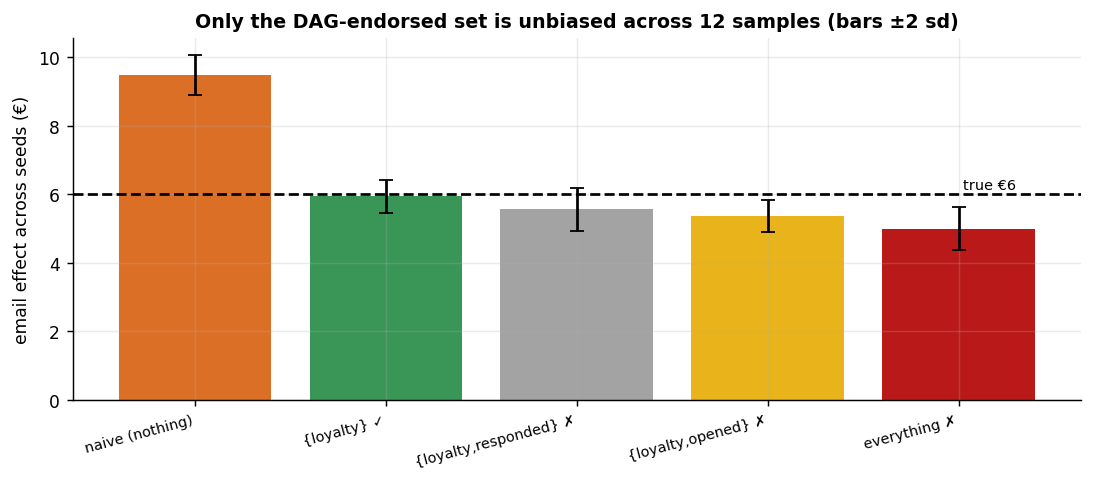

In [11]:
# --- Recovery across many seeds: which control sets are unbiased? (uncertainty on the bars) ---
NSEED = 12 if FAST else 30
allest = {k: [] for k in choices}
for sd in range(NSEED):
    ds, _tt = dgp.dag_control_demo(n=2000, seed=400 + sd)
    for k, v in choices.items():
        Xs = np.column_stack([np.ones(len(ds)), ds["email"].values] + [ds[c].values for c in v])
        allest[k].append(np.linalg.lstsq(Xs, ds["spend"].values, rcond=None)[0][1])
means = np.array([np.mean(allest[k]) for k in choices]); sds = np.array([np.std(allest[k]) for k in choices])
fig, ax = plt.subplots(figsize=(8.5, 3.8))
cols = [plots.ORANGE, plots.GREEN, plots.GREY, plots.GOLD, "#b30000"]
ax.bar(range(len(choices)), means, yerr=1.96 * sds, capsize=4, color=cols, alpha=0.9)
ax.axhline(true_ate, color="k", ls="--"); ax.text(4.3, true_ate + 0.15, f"true €{true_ate:.0f}", ha="right", fontsize=8)
ax.set_xticks(range(len(choices))); ax.set_xticklabels(list(choices.keys()), rotation=15, ha="right", fontsize=8)
ax.set_ylabel("email effect across seeds (€)"); ax.set_title(f"Only the DAG-endorsed set is unbiased across {NSEED} samples (bars ±2 sd)")
fig.tight_layout()
for k in choices:
    a = np.array(allest[k]); print(f"{k:26s} mean €{a.mean():5.2f}  bias {a.mean()-true_ate:+.2f}  sd {a.std():.2f}")
dag_key = next(k for k in choices if "✓" in k)
dag_bias = float(np.mean(allest[dag_key]) - true_ate)
print(f"\nThe DAG-endorsed set is centred on the truth (bias {dag_bias:+.2f} across {NSEED} seeds — sampling "
      "noise, not a fixed offset); the collider / over-control sets carry a PERSISTENT bias\n(a fixed offset "
      "that does NOT shrink across seeds, unlike sampling noise) — exactly what a single sample can hide.")

### 5c · "But we have millions of rows" — more data does not fix a bad control set

The bars above separate noise from bias at a single sample size; the print-out *claims* the wrong sets'
offsets would not shrink with more data. Make the claim formal: for control set $W$ the OLS estimate obeys

$$
\hat\tau_W \;\xrightarrow{\;p\;}\; \tau + b_W ,
$$

where $b_W$ is a **fixed asymptotic bias** determined only by identification — which backdoor paths $W$
leaves open (the naive set) or which collider paths it opens (the kitchen-sink set). As $n \to \infty$,
sampling noise vanishes but $b_W$ does not move an inch: **more data buys precision, never validity.** We
verify by sweeping the sample size for three control sets, many fresh samples per point:

naive (nothing)    error: n=500 → +3.11±0.80   n=8,000 → +3.44±0.22


{loyalty} ✓        error: n=500 → -0.04±0.41   n=8,000 → -0.03±0.16
everything ✗       error: n=500 → -1.00±0.54   n=8,000 → -0.99±0.20


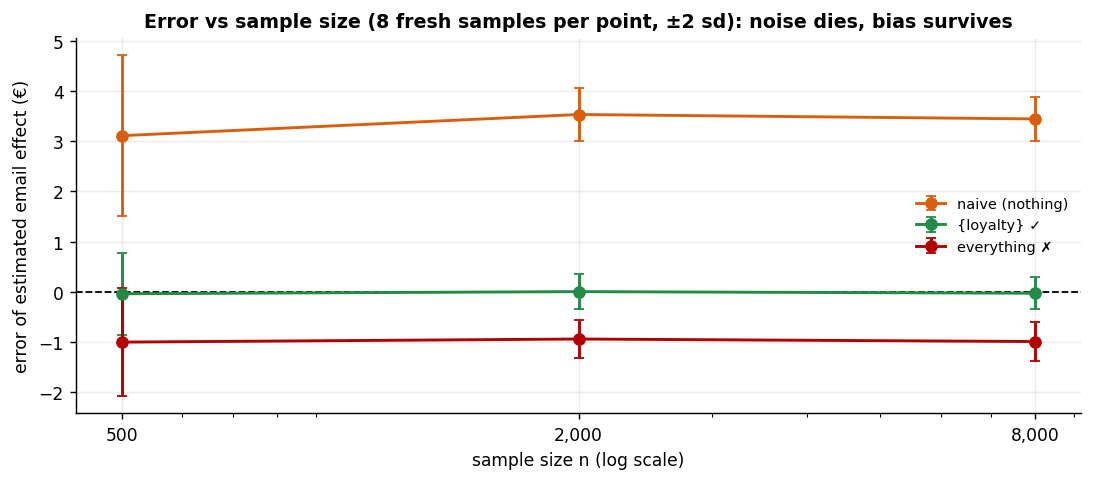

In [12]:
NS_N = 8 if FAST else 20
n_grid = [500, 2000, 8000]
sweep_sets = {"naive (nothing)": ([], plots.ORANGE), "{loyalty} ✓": (["loyalty"], plots.GREEN),
              "everything ✗": (["loyalty", "responded", "opened_email"], "#b30000")}
sweep_err = {lab: [[ols_on(dgp.dag_control_demo(n=nn, seed=700 + 37 * j)[0], ctrl) - true_ate
                    for j in range(NS_N)] for nn in n_grid]
             for lab, (ctrl, _c) in sweep_sets.items()}
fig, ax = plt.subplots(figsize=(8.5, 3.8))
for lab, (ctrl, col) in sweep_sets.items():
    e = np.array(sweep_err[lab])
    ax.errorbar(n_grid, e.mean(axis=1), yerr=2 * e.std(axis=1), marker="o", capsize=3, color=col, lw=1.6, label=lab)
ax.axhline(0, color="k", ls="--", lw=1)
ax.set_xscale("log"); ax.set_xticks(n_grid); ax.set_xticklabels([f"{n:,}" for n in n_grid])
ax.set_xlabel("sample size n (log scale)"); ax.set_ylabel("error of estimated email effect (€)")
ax.set_title(f"Error vs sample size ({NS_N} fresh samples per point, ±2 sd): noise dies, bias survives")
ax.legend(frameon=False, fontsize=8); fig.tight_layout()
for lab in sweep_sets:
    e = np.array(sweep_err[lab])
    print(f"{lab:18s} error: n=500 → {e[0].mean():+.2f}±{e[0].std():.2f}   n=8,000 → {e[2].mean():+.2f}±{e[2].std():.2f}")

**Read-out.** Every error bar narrows as $n$ grows — but only the green line narrows **around zero**. The
naive and kitchen-sink lines narrow around the wrong number: at $n = 8{,}000$ they are *more confidently
wrong* than at 500. This is the rebuttal to the pitch every CMO eventually hears — "our platform observes
millions of customers, so the numbers are rock-solid." Volume shrinks the error bars; if the adjustment set
is wrong, it shrinks them around the artifact. The first question for any vendor deck is not *how many
rows* but ***what did you control for — and what did that choice condition on?***

## 6 · Decide, in euros — the stakes of the control choice, with a robustness statement

Two parts. **(a) The euro stakes.** Getting the control set wrong isn't academic: budgeting a campaign on the
naive (confounded) estimate books *phantom* incremental revenue, which we price out below across a realistic
campaign — the concrete cost of skipping the DAG. **(b) The robustness statement.** Identification is
untestable, so we bound the residual risk: how strong would an *unobserved* confounder have to be to overturn
the conclusion? `pathmc.sensitivity` and the E-value are **two independent parameterizations of the same worry**, not one
summarising the other. The first is an **additive γ·δ contour in raw € units**: it sweeps a hidden confounder's
treatment- and outcome-associations (γ, δ) and maps where the adjusted effect `observed_ATE − γ·δ` tips through
zero — i.e. where **γ·δ ≈ the observed ATE** (the grid is widened so that zero-crossing is actually reachable).
The second is VanderWeele's **E-value**, a single number on the **risk-ratio scale**: for a continuous euro
outcome the effect is first standardized (here d ≈ 0.73 sd) and mapped to an approximate risk ratio via
RR ≈ exp(0.91·d), and the E-value reports how strong the confounder's risk-ratio associations would have to be.
Because the two live on **different scales** (raw € vs risk ratio), the E-value does *not* summarise the γ·δ
contour, and the euro effect must *not* be plotted on the E-value's axis.

And because the fit is Bayesian, a third part follows the code: we read off the **posterior of the
effect itself** and restate the GO/NO-GO as a probability instead of a point comparison.

Observed adjusted ATE €6.07 (true €6.0)  ·  E-value ≈ 3.29
An unmeasured confounder would need ~3.3× association (risk-ratio scale) with BOTH email and
spend to explain the effect away — ask the domain expert whether anything that strong is plausible.

Euro stakes: budgeting on the naive €9.45 instead of the DAG-endorsed €6.09 overstates incremental
revenue by €168,031 across a 50,000-customer campaign — phantom lift that would justify overspending on the email.

Break-even €5.00/email · E-value vs break-even ≈ 1.50 (how strong a hidden confounder must be to drag the DAG-endorsed effect below cost).
  naive (nothing)            € 9.45  ->  GO   (lift > cost)
  {loyalty} ✓                € 6.09  ->  GO   (lift > cost)
  {loyalty,responded} ✗      € 5.58  ->  GO   (lift > cost)
  {loyalty,opened} ✗         € 5.45  ->  GO   (lift > cost)
  everything ✗               € 4.97  ->  NO-GO (lift ≤ cost)
Same data, 1/5 control sets fall below the €5.00 break-even: over-controlling drags the true

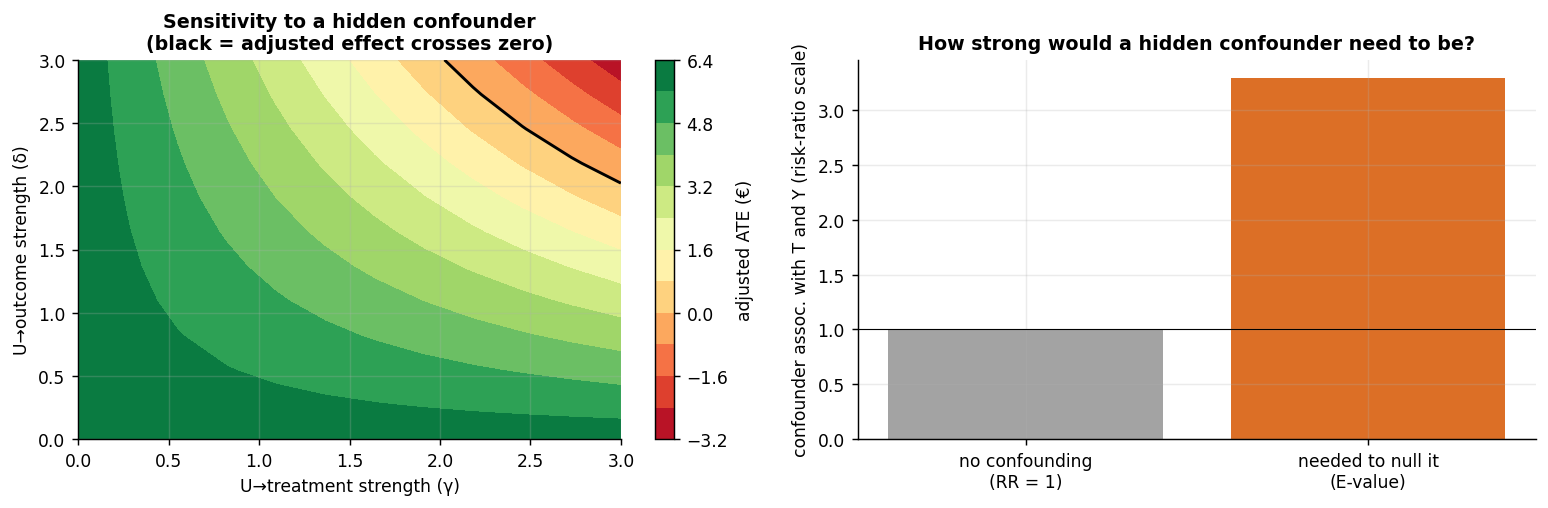

In [13]:
idata = m.fit(random_seed=SEED, progressbar=False, **FIT)
# pathmc's bias model is adjusted_ATE = observed_ATE - gamma*delta, so the grid must reach
# gamma*delta ~ the observed effect for a "crosses zero" line to exist. The default (0,1)^2 caps
# the bias at 1 (< the €6 effect) and can NEVER cross zero — we widen the ranges to (0,3)^2.
sens = m.sensitivity("spend", "email", n_grid=12, gamma_range=(0.0, 3.0), delta_range=(0.0, 3.0))
adj = np.asarray(sens.adjusted_ate_mean); COSTLINE = 0.0
evalue = metrics.e_value(float(sens.observed_ate), cost=COSTLINE, sd=float(df["spend"].std()))
print(f"Observed adjusted ATE €{float(sens.observed_ate):.2f} (true €{true_ate:.1f})  ·  E-value ≈ {evalue:.2f}")

g, d = np.meshgrid(sens.gamma_values, sens.delta_values, indexing="ij")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
cs = ax[0].contourf(g, d, adj, levels=12, cmap="RdYlGn"); ax[0].contour(g, d, adj, levels=[0], colors="k", linewidths=1.6)
plt.colorbar(cs, ax=ax[0], label="adjusted ATE (€)")
ax[0].set_xlabel("U→treatment strength (γ)"); ax[0].set_ylabel("U→outcome strength (δ)")
ax[0].set_title("Sensitivity to a hidden confounder\n(black = adjusted effect crosses zero)")
# E-value on the RISK-RATIO scale only — the euro effect does NOT belong on this axis.
ax[1].bar(["no confounding\n(RR = 1)", "needed to null it\n(E-value)"], [1.0, evalue],
          color=[plots.GREY, plots.ORANGE], alpha=0.9); ax[1].axhline(1.0, color="k", lw=0.6)
ax[1].set_ylabel("confounder assoc. with T and Y (risk-ratio scale)")
ax[1].set_title("How strong would a hidden confounder need to be?")
fig.tight_layout()
print(f"An unmeasured confounder would need ~{evalue:.1f}× association (risk-ratio scale) with BOTH email and\n"
      f"spend to explain the effect away — ask the domain expert whether anything that strong is plausible.")

# The euro stakes of the control choice: budgeting on the naive (confounded) estimate books phantom lift.
CAMPAIGN_N = 50_000
naive_ate, correct_ate = ests["naive (nothing)"], ests["{loyalty} ✓"]
overstatement = (naive_ate - correct_ate) * CAMPAIGN_N
print(f"\nEuro stakes: budgeting on the naive €{naive_ate:.2f} instead of the DAG-endorsed €{correct_ate:.2f} "
      f"overstates incremental\nrevenue by €{overstatement:,.0f} across a {CAMPAIGN_N:,}-customer campaign — "
      f"phantom lift that would justify overspending on the email.")

# Business break-even: a plausible per-email cost turns each ATE into a go/no-go, and shows which control
# choice would FLIP the campaign decision. The E-value is now measured against break-even (not zero).
COST = 5.0  # fully-loaded € per targeted contact (email + the offer it carries) — pays only if the lift clears this
evalue_be = metrics.e_value(float(sens.observed_ate), cost=COST, sd=float(df["spend"].std()))
print(f"\nBreak-even €{COST:.2f}/email · E-value vs break-even ≈ {evalue_be:.2f} "
      f"(how strong a hidden confounder must be to drag the DAG-endorsed effect below cost).")
for k, v in ests.items():
    verdict = "GO   (lift > cost)" if v > COST else "NO-GO (lift ≤ cost)"
    print(f"  {k:26s} €{v:5.2f}  ->  {verdict}")
n_below = sum(v <= COST for v in ests.values())
print(f"Same data, {n_below}/{len(ests)} control sets fall below the €{COST:.2f} break-even: over-controlling drags "
      f"the true €{true_ate:.1f}\neffect below cost, so the kitchen-sink set would wrongly KILL a campaign the "
      f"DAG-endorsed {{loyalty}} set green-lights — the control choice is a business call, not a technicality.")
print(f"control model convergence: {est.convergence_report(idata)["summary"]}")


### The Bayesian read — how sure are we, and of what?

Every GO/NO-GO in the table above compared a *point estimate* to the €5 break-even — thin ice for a
Bayesian cookbook. The `m.fit(...)` that powered the sensitivity grid is a full posterior over every
structural coefficient, so we already own the entire distribution of the email effect **under the endorsed
set $\{loyalty\}$**. The honest decision statement replaces "point estimate > €5" with two probabilities:
$P(\tau > 0)$ — is there any effect — and $P(\tau > \text{cost})$ — does it pay.

posterior mean €6.07   ·   94% HDI [€5.59, €6.51]
P(τ > 0) = 1.000   ·   P(τ > €5 break-even) = 1.000
Decision, restated honestly: GO with P(lift > cost) = 1.00 under the DAG-endorsed adjustment set — a probability, not a point comparison.


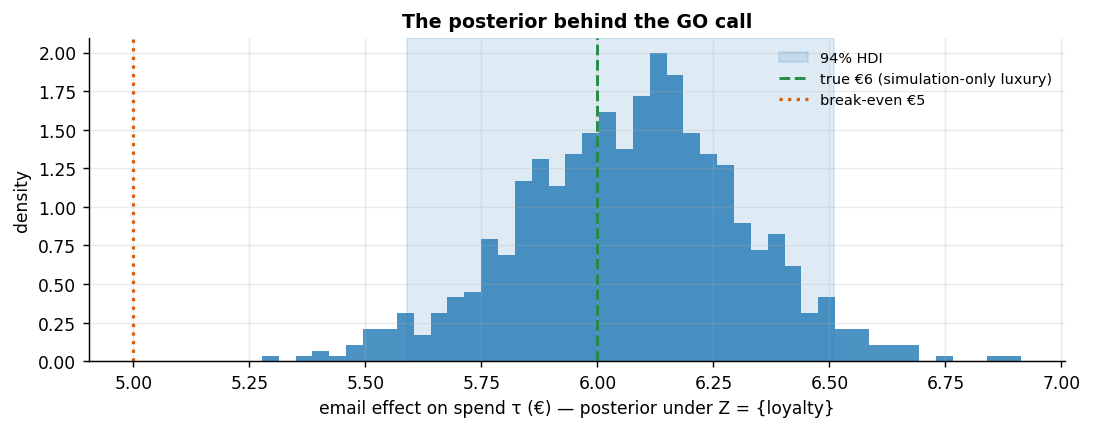

In [14]:
tau_draws = idata.posterior["beta_spend"].sel(spend_predictors="email").values.ravel()

def hdi94(x, prob=0.94):                      # shortest interval holding `prob` of the posterior mass
    xs = np.sort(np.asarray(x)); n_ = len(xs); k = int(np.floor(prob * n_))
    i = int(np.argmin(xs[k:] - xs[:n_ - k]))
    return float(xs[i]), float(xs[i + k])

lo94, hi94 = hdi94(tau_draws)
p_pos, p_cost = float((tau_draws > 0).mean()), float((tau_draws > COST).mean())
fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.hist(tau_draws, bins=45, color=plots.BLUE, alpha=0.85, density=True)
ax.axvspan(lo94, hi94, color=plots.BLUE, alpha=0.15, label="94% HDI")
ax.axvline(true_ate, color=plots.GREEN, ls="--", lw=1.6, label=f"true €{true_ate:.0f} (simulation-only luxury)")
ax.axvline(COST, color=plots.ORANGE, ls=":", lw=1.8, label=f"break-even €{COST:.0f}")
ax.set_xlabel("email effect on spend τ (€) — posterior under Z = {loyalty}"); ax.set_ylabel("density")
ax.set_title("The posterior behind the GO call")
ax.legend(frameon=False, fontsize=8); fig.tight_layout()
print(f"posterior mean €{tau_draws.mean():.2f}   ·   94% HDI [€{lo94:.2f}, €{hi94:.2f}]")
print(f"P(τ > 0) = {p_pos:.3f}   ·   P(τ > €{COST:.0f} break-even) = {p_cost:.3f}")
print(f"Decision, restated honestly: GO with P(lift > cost) = {p_cost:.2f} under the DAG-endorsed adjustment set "
      "— a probability, not a point comparison.")

**Read-out.** Identification (Steps 3–5) chose *which* number the posterior concentrates on; the posterior
says *how sure* to be of that number. Here the whole 94% HDI sits above the €5 break-even, so
$P(\text{lift} > \text{cost})$ prints at essentially 1 and the GO is not riding a knife's edge — if the HDI
straddled the cost line, the same plot would say "test before you spend" (nb01's straddler logic). One
warning label, and it matters: **this width is honest only under the endorsed adjustment set.** Refit the
same model with the kitchen-sink controls and the machinery would hand you an interval that looks every bit
as tight — centred on the biased number. A tight posterior around a collider-biased point is *confidently
wrong*: precision quantifies sampling noise, never identification error. That is §4's "the model can't tell
you it's biased," now in Bayesian dress.

## 6b · The stakes on **real** data (LaLonde) — good vs bad adjustment

This isn't an academic worry, and it isn't confined to toy graphs. The famous **LaLonde (1986) /
Dehejia–Wahba** job-training data pairs a randomized experiment — benchmark effect on 1978 earnings
≈ \$1,800 — with an observational comparison group drawn from population surveys, so observational
adjustment choices can be *scored* against an experimental answer. The cell below prints three reads of the
same observational data:

- **naive** (no controls) — the trainees were far poorer than the survey comparison group before the
  program existed, so the raw gap is dominated by selection;
- **bad adjustment** — demographics only (age, education, race, marital status, degree), *dropping* the two
  pre-program earnings years `re74`/`re75`. It looks responsible — six pre-treatment covariates! — but
  Dehejia & Wahba's core finding is that the pre-earnings variables are the **load-bearing confounders**;
- **good adjustment** — the same regression *plus* `re74`/`re75`, the full standard pre-treatment set.

The data is fetched from a public URL (you provide nothing) and the section is gated on `CMP_REAL=1` so
offline runs skip it; the committed notebook ships with the gated branch **executed**, and the read-out
below refers to those printed numbers.

In [15]:
if os.environ.get("CMP_REAL") == "1":
    from cmp import data
    ll = data.load_lalonde()
    T2, Y2 = ll["treat"].values, ll["re78"].values
    good = ["age", "educ", "black", "hispan", "married", "nodegree", "re74", "re75"]  # + pre-program earnings
    bad = ["age", "educ", "black", "hispan", "married", "nodegree"]                   # demographics only
    def lalonde_adj(cols):
        D = np.column_stack([np.ones(len(ll)), T2, ll[cols].values])
        return np.linalg.lstsq(D, Y2, rcond=None)[0][1]
    naive2 = Y2[T2 == 1].mean() - Y2[T2 == 0].mean()
    print("Effect of job training on 1978 earnings (observational comparison group, n="
          f"{len(ll)}):")
    print(f"  naive — no controls                        : ${naive2:>7,.0f}")
    print(f"  BAD adjust — demographics, NO re74/re75    : ${lalonde_adj(bad):>7,.0f}")
    print(f"  GOOD adjust — demographics + re74/re75     : ${lalonde_adj(good):>7,.0f}")
    print(f"  experimental benchmark (RCT reference)     : ≈ $1,800")
    print(f"why the naive fails: 1974 earnings were ${ll.loc[ll.treat == 1, 're74'].mean():,.0f} (future trainees) vs "
          f"${ll.loc[ll.treat == 0, 're74'].mean():,.0f} (comparison group) — the groups were never comparable.")
else:
    print("Real-data section skipped. Set CMP_REAL=1 and re-run to fetch the LaLonde dataset.")

Effect of job training on 1978 earnings (observational comparison group, n=614):
  naive — no controls                        : $   -635
  BAD adjust — demographics, NO re74/re75    : $  1,164
  GOOD adjust — demographics + re74/re75     : $  1,548
  experimental benchmark (RCT reference)     : ≈ $1,800
why the naive fails: 1974 earnings were $2,096 (future trainees) vs $5,619 (comparison group) — the groups were never comparable.


**Read-out (gated run).** The naive comparison does not merely miss the benchmark — on this composite it
comes out **negative**, "training *reduced* earnings," because the comparison group out-earned the trainees
years before the program existed (the last printed line quantifies the pre-program gap). Adjusting for
demographics alone repairs the sign but still lands well short of the good specification; restoring the two
pre-program earnings years moves the estimate within a few hundred dollars of the ≈ \$1,800 experimental
answer. Same data, three defensible-*sounding* specifications, three different stories — and choosing among
them is exactly the §3 skill: prior earnings are the strongest plausible common cause of *enrolling in the
program* and *earning later*, so the backdoor criterion demands them in $Z$. Dropping a load-bearing
confounder is the mirror image of adding a collider: both are identification failures no estimator or
sample size repairs (§5c). *(If you re-executed this notebook without `CMP_REAL=1`, the numbers referenced
here are in the committed output; re-run the gated branch before quoting them elsewhere.)*

## 7 · From the toy graph to your CRM — a practitioner's covariate checklist

The intro promised to tell you which columns of *your* campaign table belong in the model. The toy
variables map one-to-one onto the fields every marketing dataset carries:

| variable (as measured) | likely causal role | action |
|---|---|---|
| loyalty tier, RFM score computed **before** send, region, seasonality, prior-quarter spend | confounder — drives both targeting and spend | **control** |
| opens, clicks, site visits **after** the send | mediator — or hidden collider via latent engagement (§4's `opened_email`) | **exclude** when the question is the total effect |
| responded / converted / unsubscribed | collider (post-outcome) | **exclude — and never filter on it** (§4b) |
| survey participation, post-campaign app install | selection collider | **exclude**; distrust any panel filtered on them |
| pre-treatment *proxy* of an unmeasured trait (e.g. historical open-rate, coupon history) | it depends — draw the graph | M-bias risk if it is a common effect of latents (§1c) |

Pocket rule: **pre-treatment AND a plausible common cause of $T$ and $Y$ ⇒ in; caused by $T$ ⇒ out;
anything else ⇒ draw the DAG.** A timestamp is a heuristic; the graph is the criterion — and when in doubt
between "possible confounder" and "possible M-collider," §1c's magnitude argument says adjusting is usually
the lesser evil.

### The one-paragraph decision

> We estimate the email's effect on spend adjusting for **`{loyalty}` only** — the set the backdoor
> criterion selects and the only candidate that survives falsification against the data
> (`opened_email` fails its implied-independence test, so it stays out even though the *declared* graph
> green-lit it). Under that set the effect is ≈ €6 with the 94% HDI printed above, clearing the €5
> break-even with $P(\text{lift} > \text{cost}) \approx 1$: **GO**. Robustness: a hidden confounder would
> need roughly a 3× risk-ratio association with *both* treatment and outcome to null the effect, and about
> 1.5× to drag it below break-even — the second number is the one to debate with the domain expert. The
> control choice is not a technicality: budgeting on the naive read books ≈ €170k of phantom revenue on a
> 50,000-customer campaign, and the kitchen-sink set flips this true-GO campaign to NO-GO. Residual risk is
> the graph itself, so the follow-up is not a bigger model — it is re-running `test_implications` on each
> quarter's fresh data and re-drawing the DAG the moment the data rejects an implication.

In [16]:
import json
decision = {
    "adjustment_set": ["loyalty"],
    "ate_hat_posterior_mean": round(float(tau_draws.mean()), 2),
    "hdi94": [round(lo94, 2), round(hi94, 2)],
    "p_gt_zero": round(p_pos, 3),
    "p_gt_cost": round(p_cost, 3),
    "e_value_null": round(float(evalue), 2),
    "e_value_breakeven": round(float(evalue_be), 2),
    "phantom_revenue_naive_eur": round(float(overstatement)),
    "decision_flipping_sets": [k for k, v in ests.items() if (v > COST) != (ests["{loyalty} ✓"] > COST)],
    "dag_falsification": {"n_tests": int(falsif.n_tests), "n_violations": int(falsif.n_violations)},
}
print(json.dumps(decision, indent=2, ensure_ascii=False))

{
  "adjustment_set": [
    "loyalty"
  ],
  "ate_hat_posterior_mean": 6.07,
  "hdi94": [
    5.59,
    6.51
  ],
  "p_gt_zero": 1.0,
  "p_gt_cost": 1.0,
  "e_value_null": 3.29,
  "e_value_breakeven": 1.5,
  "phantom_revenue_naive_eur": 168031,
  "decision_flipping_sets": [
    "everything ✗"
  ],
  "dag_falsification": {
    "n_tests": 4,
    "n_violations": 1
  }
}


## 8 · Caveats

- **The graph is an assumption.** `pathmc` gives the correct set *for the DAG you drew*. A missing
  or reversed edge changes the advice — the DAG must encode defensible domain knowledge.
- **Colliders hide in "obvious" controls.** "engaged", "responded", "opened", "clicked" are almost
  always post-treatment; excluding them feels wrong to practitioners and is exactly right.
- **Front-door as a fallback.** If a T–Y confounder is genuinely unmeasured but a fully-mediating
  measured variable exists, the front-door adjustment can still identify the effect — a tool to
  keep in reserve (notebook 04 builds the mediation machinery front-door leans on; full front-door
  identification needs assumptions beyond nb04's scope).
- **Sensitivity ≠ proof.** A high E-value means "robust to plausible hidden confounding," not
  "unconfounded." Pair it with the expert's judgement about what could be missing.
